# Label Propagation

Reproduces the results for `APORIA-LP` (**Section 4.2** and **Appendix C.3** of the paper) — the main label-propagation experiment and its performance tables (Figure 8, Table 2).  
Complements also the results for the stemmed responses (Table 9) and for CoQA dataset (Table 12).

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)

os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.  Switching to a
# different dataset (e.g. CoQA) is a one-line change.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose the names downstream plotting cells still use
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
maxResponsesPerPrompt = cfg.dataset.max_responses_per_prompt


In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [5]:
df = ap.load_dataframe(cfg)


In [6]:
model_order, model_rank = ap.build_model_size_order(cfg)

false_premise = (
    {pid: fp for pid, fp in df[["prompt_id", "false_premise"]].value_counts().keys()}
    if "false_premise" in df.columns
    else None
)


## Experiment

In [7]:
results_df, geometry_store, null_store = ap.run_structural_analysis(
    df, cfg,
    use_cache=True,
    overwrite_cache=False,
)


Cache correctly loaded.


In [8]:
results_lp_max = ap.run_full_label_propagation_study(
    df, cfg,
    projector_class=ap.FisherProjection,
    projector_kwargs={
        "lambda_reg":          best_reg_lambda,
        "normalise":           True,
        "normalise_by_trace":  True,
    },
    train_fractions=None,
    n_iter=20,
    test_fraction=1/3,
    n_splits=20,
    ref_lambda_reg=None,
    use_cache=True,
    cache_dir=f"{cfg.cache.root}/LP-fisher",
    overwrite_cache=False,
    logskip=True,
)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

## Performances of APORIA-LP -- Fig. 8

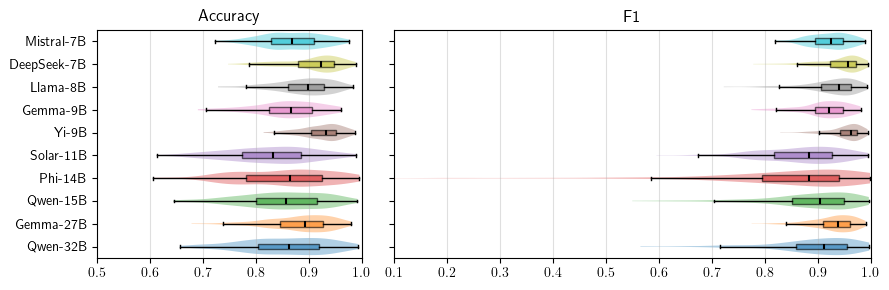

In [9]:
fig, _ = ap.plot_metric_boxplots_two_panels(
    results_lp_max,
    model_names=model_names,
    model_order=model_order,
    train_fraction=1,
    width_ratios=[5, 9],
    xlims=[(0.5, 1.0), (.1, 1.0)],
    ratio=(3,1),
    scale=3
)

# fig.savefig(f"{figures_dir}/LP_statistics.pdf", bbox_inches='tight')

## Accuracy by hallucination rate

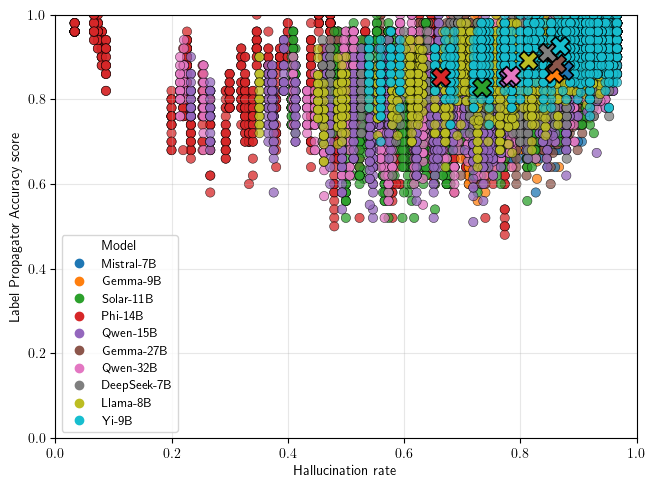

In [10]:
# Correlation beetween hall_rate and performance ?
# select relevant columns
lp_cols = [
    "model_id", "prompt_id",
    "f1",
    "accuracy",
    "precision",
    "recall",
]

struct_cols = [
    "model_id", "prompt_id",
    "n_G", "n_H", "frac_H",
    "valid_geom",
]

df_plot = (
    results_lp_max[lp_cols]
    .merge(
        results_df[struct_cols],
        on=["model_id", "prompt_id"],
        how="inner"
    )
)

# filter

df_plot = df_plot[
    (df_plot["n_G"] >= 5) &
    (df_plot["n_H"] >= 5) &
    (df_plot["valid_geom"])
].copy()

models = sorted(df_plot["model_id"].unique())
cmap = plt.get_cmap("tab10", len(models))
color_map = {m: cmap(i) for i, m in enumerate(models)}

colors = df_plot["model_id"].map(color_map)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    df_plot["frac_H"],
    df_plot["accuracy"],
    c=colors,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
    s=45,
)

ax.set_xlabel("Hallucination rate")
ax.set_ylabel("Label Propagator Accuracy score")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               color=color_map[m], label=model_names[m])
    for m in models
]
ax.legend(handles=handles, title="Model", fontsize=9, loc="lower left")

centroids = (
    df_plot
    .groupby("model_id")
    .agg(
        frac_H_mean=("frac_H", "mean"),
        accuracy_mean=("accuracy", "mean"),
        f1_mean=("accuracy", "mean"),
    )
    .reset_index()
)

ax.scatter(
    centroids["frac_H_mean"],
    centroids["accuracy_mean"],
    c=[color_map[m] for m in centroids["model_id"]],
    s=180,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    zorder=5,
    label="Model average",
)

## Performances of APORIA-LP -- Table 2 / 9

In [11]:
agg = (
    results_lp_max
    .groupby("model_id")
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        # signed margins by class
        m0_mean=("mean_margin_class_False", "mean"),
        m0_std=("std_margin_class_False", "mean"),

        m1_mean=("mean_margin_class_True", "mean"),
        m1_std=("std_margin_class_True", "mean"),

        # absolute margins by class (optional but useful)
        am0_mean=("mean_abs_margin_class_False", "mean"),
        am0_std=("std_abs_margin_class_False", "mean"),

        am1_mean=("mean_abs_margin_class_True", "mean"),
        am1_std=("std_abs_margin_class_True", "mean"),
    )
    .reset_index()
)

agg["model"] = agg["model_id"].map(model_latextags)

# Ordering
agg = agg.set_index("model_id").loc[model_order].reset_index()

# Add average row

avg_row = {
    "model_id": "avg",
    "model": r"\textbf{Average}",

    "acc_mean": agg["acc_mean"].mean(),
    "acc_std": agg["acc_std"].mean(),

    "f1_mean": agg["f1_mean"].mean(),
    "f1_std": agg["f1_std"].mean(),

    "m0_mean": agg["m0_mean"].mean(),
    "m0_std": agg["m0_std"].mean(),

    "m1_mean": agg["m1_mean"].mean(),
    "m1_std": agg["m1_std"].mean(),

    "am0_mean": agg["am0_mean"].mean(),
    "am0_std": agg["am0_std"].mean(),

    "am1_mean": agg["am1_mean"].mean(),
    "am1_std": agg["am1_std"].mean(),
}

agg = pd.concat([agg, pd.DataFrame([avg_row])], ignore_index=True)

# decorator helper



# Apply decorations

mask = agg["model_id"] != "avg"
acc_deco  = ap.rank_decor(agg.loc[mask, "acc_mean"].values)
f1_deco   = ap.rank_decor(agg.loc[mask, "f1_mean"].values)
am0_deco  = ap.rank_decor(agg.loc[mask, "am0_mean"].values)
am1_deco  = ap.rank_decor(agg.loc[mask, "am1_mean"].values)

# formatters


# Build table

rows = []
i = 0

for _, r in agg.iterrows():

    is_avg = r["model_id"] == "avg"

    rows.append({
        "Model": r["model"],

        "Accuracy": ap.apply_deco(
            ap.fmt_pct(r["acc_mean"], r["acc_std"]),
            None if is_avg else acc_deco[i]
        ),

        "F1": ap.apply_deco(
            ap.fmt_pct(r["f1_mean"], r["f1_std"]),
            None if is_avg else f1_deco[i]
        ),

        # signed margins → NO highlighting
        r"$M\,|\,y=0$": ap.fmt(r["m0_mean"], r["m0_std"], prec=1),
        r"$M\,|\,y=1$": ap.fmt(r["m1_mean"], r["m1_std"], prec=1),

        # absolute margins → highlight
        r"$|M|\,|\,y=0$": ap.apply_deco(
            ap.fmt(r["am0_mean"], r["am0_std"], prec=1),
            None if is_avg else am0_deco[i]
        ),

        r"$|M|\,|\,y=1$": ap.apply_deco(
            ap.fmt(r["am1_mean"], r["am1_std"], prec=1),
            None if is_avg else am1_deco[i]
        ),
    })

    if not is_avg:
        i += 1

# ... and export

table_df = pd.DataFrame(rows)

latex_table = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lcccccc",
)

print(latex_table)

\begin{tabular}{lcccccc}
\toprule
Model & Accuracy & F1 & $M\,|\,y=0$ & $M\,|\,y=1$ & $|M|\,|\,y=0$ & $|M|\,|\,y=1$ \\
\midrule
\MISTRAL & 86.8 (6.6) & 92.1 (4.4) & -0.1 (0.3) & -0.6 (0.3) & 0.4 (0.2) & 0.7 (0.2) \\
\DEEPSEEK & \underline{90.9 (6.2)} & \underline{94.1 (4.8)} & 0.4 (0.5) & -1.1 (0.5) & \underline{0.8 (0.3)} & \textbf{1.2 (0.4)} \\
\LLAMA & 89.1 (6.3) & 92.5 (5.7) & 0.3 (0.5) & -0.9 (0.5) & 0.7 (0.3) & 1.0 (0.3) \\
\GEMMANINE & 86.1 (7.1) & 91.5 (5.0) & -0.0 (0.4) & -0.7 (0.4) & 0.5 (0.2) & 0.7 (0.3) \\
\YI & \textbf{92.5 (4.8)} & \textbf{95.3 (3.7)} & 0.5 (0.5) & -1.1 (0.5) & \textbf{0.9 (0.3)} & \underline{1.1 (0.3)} \\
\SOLAR & 82.7 (9.1) & 86.9 (8.2) & 0.2 (0.3) & -0.5 (0.4) & 0.5 (0.2) & 0.6 (0.2) \\
\PHI & 85.2 (9.6) & 84.0 (16.8) & 0.3 (0.2) & -0.4 (0.3) & 0.4 (0.1) & 0.5 (0.2) \\
\QWENFOURTEEN & 85.0 (8.8) & 88.7 (9.1) & 0.2 (0.3) & -0.5 (0.3) & 0.4 (0.2) & 0.6 (0.2) \\
\GEMMATWENTYSEVEN & 88.3 (6.9) & 93.0 (4.5) & -0.0 (0.4) & -0.8 (0.4) & 0.6 (0.2) & 0.8 (0.3) 